In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import (MinMaxScaler, StandardScaler, OrdinalEncoder, LabelEncoder)
from scipy import stats
from scipy.special import inv_boxcox
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error)

In [2]:
df = pd.read_csv('ecommerce_estatistica_V1.csv')

In [3]:
df.head()

,produto,marca,material,preco,desconto,preco_desconto,publico_voltado,nota,avaliacoes,qtd_vendidos,sazonalidade
0,Kit 10 Cuecas Boxer Lupo Cueca Box Algodão Mas...,lupo,algodão,232.89,18,190.97,Masculino,4.5,3034,10000,6 meses menor temperatura
1,Kit Com 10 Cuecas Boxer Algodão Sem Costura Zo...,zorba,algodão,199.90,20,159.92,Masculino,4.7,5682,50000,demanda regular
2,Kit 10 Cuecas Boxer Mash Algodão Cotton Box Or...,mash,algodão,229.39,22,178.92,Masculino,4.6,1700,10000,6 meses maior temperatura
3,Kit 3 Short Jeans Feminino Cintura Alta Barato...,menina linda,jean,129.20,9,117.57,Feminino,4.4,507,1000,6 meses maior temperatura
4,Blusa + Calça Térmica Treino Futebol Criança I...,roupa zero grau,termico unissex,78.03,5,74.13,infantil:Unissex,4.7,58,100,6 meses menor temperatura


In [4]:
scaler = StandardScaler()
df['Std_preco'] = np.round(scaler.fit_transform(df[['preco']]), 2)

In [5]:
minmax = MinMaxScaler()
df['minmax_preco'] = np.round(minmax.fit_transform(df[['preco']]), 2)

In [6]:
df.head()

,produto,marca,material,preco,desconto,preco_desconto,publico_voltado,nota,avaliacoes,qtd_vendidos,sazonalidade,Std_preco,minmax_preco
0,Kit 10 Cuecas Boxer Lupo Cueca Box Algodão Mas...,lupo,algodão,232.89,18,190.97,Masculino,4.5,3034,10000,6 meses menor temperatura,1.60,0.69
1,Kit Com 10 Cuecas Boxer Algodão Sem Costura Zo...,zorba,algodão,199.90,20,159.92,Masculino,4.7,5682,50000,demanda regular,1.09,0.58
2,Kit 10 Cuecas Boxer Mash Algodão Cotton Box Or...,mash,algodão,229.39,22,178.92,Masculino,4.6,1700,10000,6 meses maior temperatura,1.55,0.68
3,Kit 3 Short Jeans Feminino Cintura Alta Barato...,menina linda,jean,129.20,9,117.57,Feminino,4.4,507,1000,6 meses maior temperatura,-0.00,0.34
4,Blusa + Calça Térmica Treino Futebol Criança I...,roupa zero grau,termico unissex,78.03,5,74.13,infantil:Unissex,4.7,58,100,6 meses menor temperatura,-0.80,0.17


In [7]:
freq = round(df['marca'].value_counts() / len(df), 2)
df['marca_freq'] = round(df['marca'].map(freq), 2)

In [8]:
df.head()

,produto,marca,material,preco,desconto,preco_desconto,publico_voltado,nota,avaliacoes,qtd_vendidos,sazonalidade,Std_preco,minmax_preco,marca_freq
0,Kit 10 Cuecas Boxer Lupo Cueca Box Algodão Mas...,lupo,algodão,232.89,18,190.97,Masculino,4.5,3034,10000,6 meses menor temperatura,1.60,0.69,0.11
1,Kit Com 10 Cuecas Boxer Algodão Sem Costura Zo...,zorba,algodão,199.90,20,159.92,Masculino,4.7,5682,50000,demanda regular,1.09,0.58,0.03
2,Kit 10 Cuecas Boxer Mash Algodão Cotton Box Or...,mash,algodão,229.39,22,178.92,Masculino,4.6,1700,10000,6 meses maior temperatura,1.55,0.68,0.03
3,Kit 3 Short Jeans Feminino Cintura Alta Barato...,menina linda,jean,129.20,9,117.57,Feminino,4.4,507,1000,6 meses maior temperatura,-0.00,0.34,0.04
4,Blusa + Calça Térmica Treino Futebol Criança I...,roupa zero grau,termico unissex,78.03,5,74.13,infantil:Unissex,4.7,58,100,6 meses menor temperatura,-0.80,0.17,0.01


In [9]:
df['sazonalidade'].unique()

<StringArray>
[     '6 meses menor temperatura',                'demanda regular',
      '6 meses maior temperatura',                'alta frequência',
 'primavera/verão/outono/inverno']
Length: 5, dtype: str

In [10]:
df['sazonalidade']= df['sazonalidade'].replace({'primavera/verão/outono/inverno':'alta frequência'})

In [11]:
ordem = ['demanda regular', '6 meses maior temperatura', '6 meses menor temperatura', 'alta frequência']

In [12]:
ordinal = OrdinalEncoder(categories=[ordem])
df['sazonalidade_ordinal'] = ordinal.fit_transform(df[['sazonalidade']])

In [13]:
freq_material = df['material'].value_counts() / len(df)
df['material_freq'] = round(df['material'].map(freq_material), 2)

In [14]:
df['publico_voltado'] = df['publico_voltado'].replace({'roupa para gordinha pluss P ao 52':'Feminino'})

In [15]:
df['publico_voltado'].unique()

<StringArray>
[         'Masculino',           'Feminino',   'infantil:Unissex',
            'Unissex', 'Infantil:masculino',  'Infantil:feminino',
              'Bebês']
Length: 7, dtype: str

In [16]:
ordem_sex = ['Masculino', 'Feminino', 'Unissex', 'infantil:Unissex', 'Infantil:masculino', 'Infantil:feminino', 'Bebês']
sex_ordinal = OrdinalEncoder(categories=[ordem_sex])

In [17]:
df['publico_voltado_ordinal'] = sex_ordinal.fit_transform(df[['publico_voltado']])

In [18]:
preco_st, lambda_preco = stats.boxcox(df['preco'] + 1)

In [19]:
df['preco_sts'] = np.round(preco_st, 2)

In [20]:
df['preco_desconto_minmax'] = np.round(minmax.fit_transform(df[['preco_desconto']]), 2)

In [21]:
df['preco_desconto_std'] = np.round(scaler.fit_transform(df[['preco_desconto']]), 2)

In [22]:
preco_desconto_sts, lambda_preco_desconto = stats.boxcox(df['preco_desconto'] + 1)

In [23]:
df['preco_desconto_sts'] = np.round(preco_desconto_sts, 2)

In [24]:
df.head()

,produto,marca,material,preco,desconto,preco_desconto,publico_voltado,nota,avaliacoes,qtd_vendidos,...,Std_preco,minmax_preco,marca_freq,sazonalidade_ordinal,material_freq,publico_voltado_ordinal,preco_sts,preco_desconto_minmax,preco_desconto_std,preco_desconto_sts
0,Kit 10 Cuecas Boxer Lupo Cueca Box Algodão Mas...,lupo,algodão,232.89,18,190.97,Masculino,4.5,3034,10000,...,1.60,0.69,0.11,2.0,0.39,0.0,14.88,0.59,1.60,15.35
1,Kit Com 10 Cuecas Boxer Algodão Sem Costura Zo...,zorba,algodão,199.90,20,159.92,Masculino,4.7,5682,50000,...,1.09,0.58,0.03,0.0,0.39,0.0,14.02,0.48,1.01,14.25
2,Kit 10 Cuecas Boxer Mash Algodão Cotton Box Or...,mash,algodão,229.39,22,178.92,Masculino,4.6,1700,10000,...,1.55,0.68,0.03,1.0,0.39,0.0,14.79,0.54,1.37,14.94
3,Kit 3 Short Jeans Feminino Cintura Alta Barato...,menina linda,jean,129.20,9,117.57,Feminino,4.4,507,1000,...,-0.00,0.34,0.04,1.0,0.06,1.0,11.79,0.33,0.20,12.50
4,Blusa + Calça Térmica Treino Futebol Criança I...,roupa zero grau,termico unissex,78.03,5,74.13,infantil:Unissex,4.7,58,100,...,-0.80,0.17,0.01,2.0,0.00,3.0,9.58,0.18,-0.63,10.21


In [25]:
df['minmax_avaliacoes'] = np.round(minmax.fit_transform(df[['avaliacoes']]), 2)

In [26]:
df['std_avaliacoes'] = np.round(scaler.fit_transform(df[['avaliacoes']]), 2)

In [27]:
vendas, lambda_vendas = stats.boxcox(df['qtd_vendidos'] + 1)

In [28]:
df['qtd_vendidos_sts'] = np.round(vendas, 2)

In [29]:
label = LabelEncoder()
df['cod_produto'] = label.fit_transform(df['produto'])

In [30]:
df['freq_produto'] = np.round(df['cod_produto'].value_counts() / len(df), 2)

In [31]:
df.head()

,produto,marca,material,preco,desconto,preco_desconto,publico_voltado,nota,avaliacoes,qtd_vendidos,...,publico_voltado_ordinal,preco_sts,preco_desconto_minmax,preco_desconto_std,preco_desconto_sts,minmax_avaliacoes,std_avaliacoes,qtd_vendidos_sts,cod_produto,freq_produto
0,Kit 10 Cuecas Boxer Lupo Cueca Box Algodão Mas...,lupo,algodão,232.89,18,190.97,Masculino,4.5,3034,10000,...,0.0,14.88,0.59,1.60,15.35,0.33,2.33,5.00,85,0.01
1,Kit Com 10 Cuecas Boxer Algodão Sem Costura Zo...,zorba,algodão,199.90,20,159.92,Masculino,4.7,5682,50000,...,0.0,14.02,0.48,1.01,14.25,0.63,4.76,5.37,158,0.00
2,Kit 10 Cuecas Boxer Mash Algodão Cotton Box Or...,mash,algodão,229.39,22,178.92,Masculino,4.6,1700,10000,...,0.0,14.79,0.54,1.37,14.94,0.19,1.11,5.00,87,0.00
3,Kit 3 Short Jeans Feminino Cintura Alta Barato...,menina linda,jean,129.20,9,117.57,Feminino,4.4,507,1000,...,1.0,11.79,0.33,0.20,12.50,0.06,0.02,4.31,125,0.00
4,Blusa + Calça Térmica Treino Futebol Criança I...,roupa zero grau,termico unissex,78.03,5,74.13,infantil:Unissex,4.7,58,100,...,3.0,9.58,0.18,-0.63,10.21,0.01,-0.39,3.34,16,0.00


In [32]:
df.drop(columns=['marca', 'material', 'publico_voltado', 'sazonalidade', 'avaliacoes', 'desconto'], inplace=True)

In [33]:
df.to_csv('ecommerce_estatistica_V2.csv', index=False)

In [34]:
corr = df[['nota', 'preco', 'sazonalidade_ordinal', 'qtd_vendidos', 'publico_voltado_ordinal', 'material_freq', 'preco', 'preco_desconto']].corr()

<Axes: >

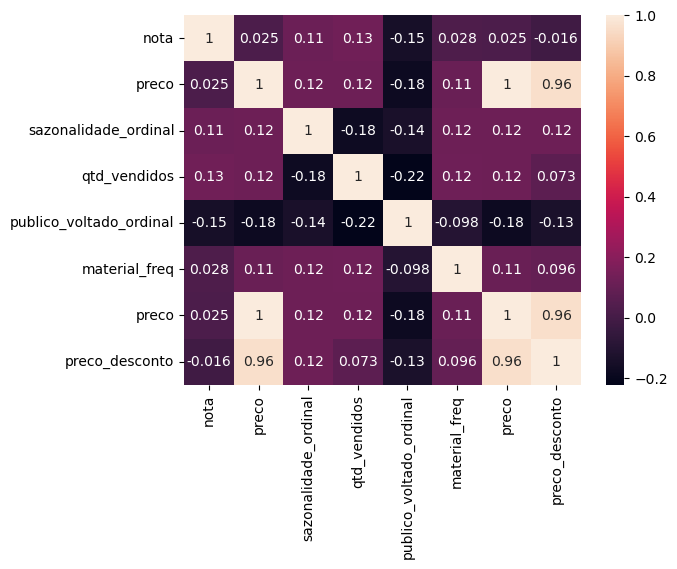

In [35]:
sns.heatmap(corr, annot=True)

<Axes: xlabel='preco', ylabel='nota'>

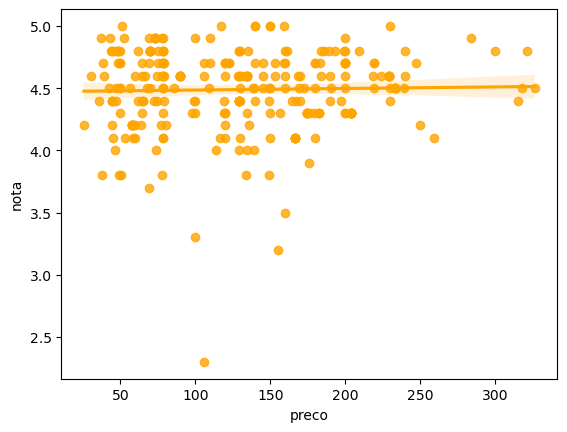

In [36]:
sns.regplot(x='preco', y='nota', data=df, color='orange')

In [37]:
X = df[['minmax_preco', 'Std_preco', 'material_freq', 'publico_voltado_ordinal', 'sazonalidade_ordinal',
        'preco_desconto_minmax', 'preco_desconto_std', 'minmax_avaliacoes', 'std_avaliacoes']]

Y = df[['qtd_vendidos_sts', 'preco_desconto', 'publico_voltado_ordinal']]

In [38]:
X_train, X_teste, Y_train, Y_teste = train_test_split(X, Y, test_size=0.25, random_state=47)

In [39]:
modelo = RandomForestRegressor()
modelo.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [40]:
Y_prev = modelo.predict(X_teste)

In [41]:
r2 = r2_score(Y_teste, Y_prev)
round(r2, 2)

0.56

In [42]:
squad_error = mean_absolute_error(Y_teste, Y_prev)
round(squad_error, 2)

0.65

In [48]:
qtd_prev = Y_prev[:, 0]
preco_desconto_prev = np.round(Y_prev[:, 1],2)
publico_prev = np.round(Y_prev[:, 2], 0)

In [44]:
qtd_final = (inv_boxcox(Y_prev[:, 0], lambda_vendas) -1).astype(int)
qtd_final

array([  125,   329,   140,   101,  1079,   206,    79,   125,    30,
         319,   120,   998,   962,    94,   962,  9812,   962, 45975,
         508,    49,  3911,    99,   338,   390,   190,    79,   236,
         423,   102,  8392,   998,   238,   128,   232,  8460,   998,
         652,   211,   998,   386,   417,   360,    55,  1958,  3911,
         151,   134,   962,   175,   972,   253,    90,   245,    95,
         338,   409,   998,    83,   962,   135,  9812,   972,   100,
         240,    65,   162,   110,   101,   161,   117,   125,  3911])

In [49]:
preco_desconto_prev

array([ 28.56, 154.9 , 268.82, 126.25,  69.81, 103.53, 127.15,  79.39,
       122.78,  32.74,  45.99, 154.95, 166.1 , 108.34, 149.56,  70.12,
       149.56, 159.9 , 179.7 , 143.24, 191.36, 128.42, 150.21,  39.79,
       129.12, 103.32,  58.44, 116.88, 113.29,  36.89, 154.95,  54.33,
        79.45,  78.73, 178.94, 154.95,  41.61,  76.03, 154.95,  60.66,
       117.08,  41.64,  96.51, 159.7 , 191.36,  44.03,  31.01, 149.56,
        64.58, 117.56,  54.39,  70.09,  42.82,  45.1 , 150.21,  60.8 ,
        51.56,  74.01, 165.53,  60.22,  48.99, 117.56,  64.82,  54.37,
       121.71, 178.4 ,  26.89,  69.73, 191.88,  47.14,  41.91, 191.36])

In [46]:
publico_prev

array([2., 2., 0., 1., 1., 1., 2., 1., 0., 1., 3., 2., 0., 2., 2., 0., 2.,
       0., 2., 0., 0., 1., 1., 1., 1., 1., 2., 1., 1., 0., 2., 1., 1., 1.,
       0., 2., 1., 1., 2., 1., 1., 1., 0., 1., 0., 2., 1., 2., 1., 1., 1.,
       1., 3., 2., 1., 1., 1., 2., 1., 1., 0., 1., 1., 1., 0., 0., 2., 1.,
       1., 3., 1., 0.])

In [47]:
df.head(2)

,produto,preco,preco_desconto,nota,qtd_vendidos,Std_preco,minmax_preco,marca_freq,sazonalidade_ordinal,material_freq,publico_voltado_ordinal,preco_sts,preco_desconto_minmax,preco_desconto_std,preco_desconto_sts,minmax_avaliacoes,std_avaliacoes,qtd_vendidos_sts,cod_produto,freq_produto
0,Kit 10 Cuecas Boxer Lupo Cueca Box Algodão Mas...,232.89,190.97,4.5,10000,1.60,0.69,0.11,2.0,0.39,0.0,14.88,0.59,1.60,15.35,0.33,2.33,5.00,85,0.01
1,Kit Com 10 Cuecas Boxer Algodão Sem Costura Zo...,199.90,159.92,4.7,50000,1.09,0.58,0.03,0.0,0.39,0.0,14.02,0.48,1.01,14.25,0.63,4.76,5.37,158,0.00


In [55]:
produto = df.loc[Y_teste.index, 'produto'].values

In [57]:
df_final = pd.DataFrame({
    "Produto":produto,
    "Quantidade_prevista":qtd_final,
    "Preco_desconto_Previsto":preco_desconto_prev,
    "Publico Alvo":publico_prev
})

In [58]:
df_final.head()

,Produto,Quantidade_prevista,Preco_desconto_Previsto,Publico Alvo
0,Calça Leg Lisa Cós Alto Suplex,125,28.56,2.0
1,Kit 6 Cuecas Box Sem Costura Boxer Lupo Microf...,329,154.90,2.0
2,Calça Levi's 501 Original Masculina 100% Algod...,140,268.82,0.0
3,Kit 5 Cuecas Anti Assadura Sem Atrito Academia...,101,126.25,1.0
4,Kit 3 Cuecas Boxer Lupo Tamanho Plus Size Masc...,1079,69.81,1.0


In [59]:
df_final.to_csv('Resultado_previsto.csv', index=False)